In [55]:
from src.imports import *
#remove warnings
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

#open figs folder txt file to read the path
with open('./fig_folder.txt', 'r') as f:
    fig_folder = f.read().strip()

## Model comparison

### Full model vs. only topic alignment vs. only peer influence

In [56]:
if os.path.exists(f"./results/loo_comparison.csv"):
    loo_comparison = pd.read_csv(f"./results/loo_comparison.csv", index_col=0)
    print(loo_comparison)
else:
    models = ['regression','tau','phi']
    fits = {}
    for model_name in models:
        with open(f"./results/stan_output/{model_name}/gpt/model_{model_name}_fit.pkl", "rb") as f:
            fit = pickle.load(f)
        fits[model_name] = fit


    #model comparison using loo
    idata_regression = az.from_cmdstanpy(fits['regression'], log_likelihood="log_lik")
    idata_phi_only = az.from_cmdstanpy(fits['phi'], log_likelihood="log_lik")
    idata_tau_only = az.from_cmdstanpy(fits['tau'], log_likelihood="log_lik")

    #close files to make memory available
    for fit in fits.values():
        fit.stan_fit.io.close()

    #loo comparison
    loo_comparison = az.compare(
        {
            "regression": idata_regression,
            "phi_only": idata_phi_only,
            "tau_only": idata_tau_only,
        },
    method="stacking"
    )
    print(loo_comparison)

    loo_comparison.to_csv(f"./results/loo_comparison.csv")

#which model is best?
best_model = loo_comparison.index[0]
print(f"Best model: {best_model}")

            rank     elpd       p  elpd_diff  weight    se   dse  warning
regression     0 -28900.0  1260.1        0.0    0.97  57.0   0.0    False
tau_only       1 -29500.0  1260.8      560.0    0.00  50.0  30.0    False
phi_only       2 -29640.0  1308.4      700.0    0.03  46.0  36.0    False
Best model: regression


### GPT vs. sentence-BERT

#### Compare annotations

In [57]:
debate_classification_gpt = pd.read_pickle('./data/processed/pkl/debate_classification_gpt.pkl')
debate_classification_bert = pd.read_pickle('./data/processed/pkl/debate_classification_bert.pkl')

df= debate_classification_gpt.merge(debate_classification_bert, on='debate_key', suffixes=('_gpt', '_bert'))

import krippendorff
def compute_krippendorff_alpha(x: list[int], y: list[int]):
    # Format data into a reliability matrix (rows=raters, cols=items)
    data_krippendorff = np.array([x, y])# Compute Krippendorff's Alpha (interval metric)
    kripp_alpha = krippendorff.alpha(reliability_data=data_krippendorff,level_of_measurement='nominal')
    return kripp_alpha

print("Krippendorff's Alpha:",
compute_krippendorff_alpha(df.topic_bert.tolist(), df.topic_gpt.tolist()))

Krippendorff's Alpha: 0.5451366284105631


#### Compare estimates

In [58]:
summary_bert = pd.read_csv("./results/regression/bert/summary.csv", index_col=0)
summary_gpt = pd.read_csv("./results/regression/gpt/summary.csv", index_col=0)

topic_mapping_bert = pd.read_pickle("./results/regression/bert/topic_mapping.pkl")
topic_mapping_gpt = pd.read_pickle("./results/regression/gpt/topic_mapping.pkl")

Weighted correlation for phi: 0.825
Weighted correlation for tau: 0.670


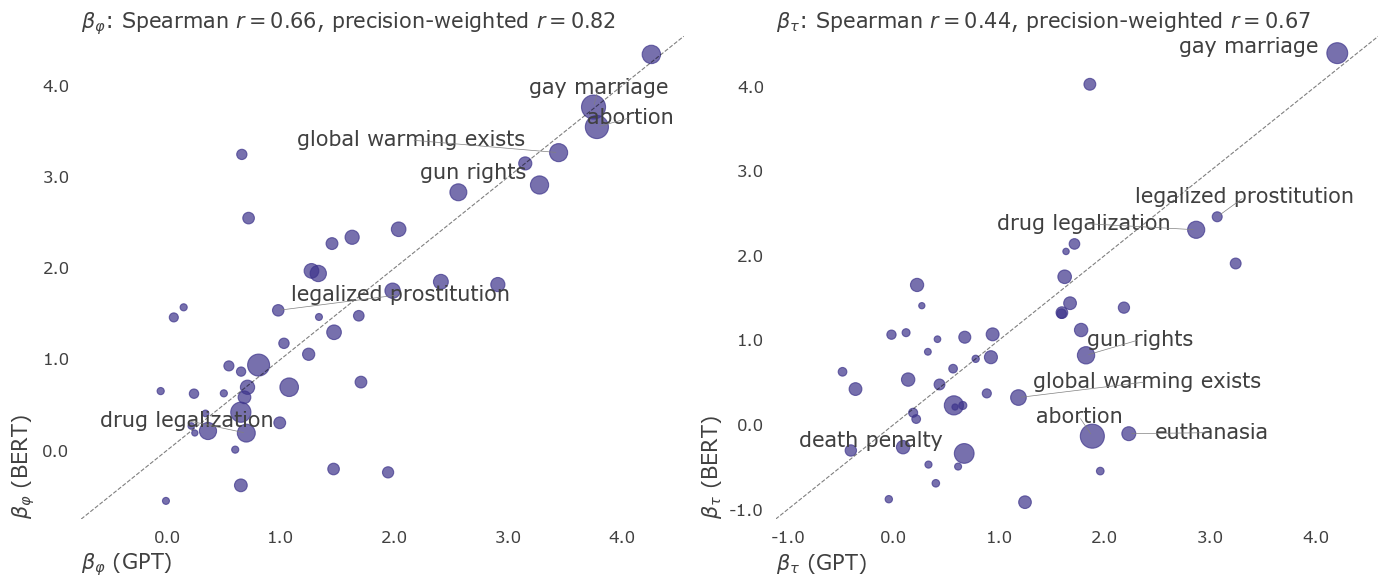

In [59]:
def betas_df(summary_df, topic_mapping):
    '''
    Extract beta_phi and beta_tau from the summary dataframe, add topic names, and return two separate dataframes.
        - summary_df: DataFrame with model summary statistics
        - topic_mapping: Dictionary mapping topic indices to topic names
    Returns:
        - beta_phi_df: DataFrame with beta_phi parameters and topic names
        - beta_tau_df: DataFrame with beta_tau parameters and topic names
    '''
    beta_phi_df = summary_df.loc[summary_df.index.str.startswith('beta_phi')].copy()
    beta_tau_df = summary_df.loc[summary_df.index.str.startswith('beta_tau')].copy()

    for df in [beta_phi_df, beta_tau_df]:
        df['topic_idx'] = (
            df.index.astype(str)
            .str.extract(r'\[\s*(\d+)\s*\]', expand=False)
            .astype('Int64')
        )
        df['topic'] = df['topic_idx'].map(topic_mapping)


    cols = ['topic', 'Mean', '5%', '95%']
    return beta_phi_df[cols], beta_tau_df[cols]

beta_phi_gpt, beta_tau_gpt = betas_df(summary_gpt, topic_mapping_gpt)
beta_phi_bert, beta_tau_bert = betas_df(summary_bert, topic_mapping_bert)

for df in [beta_phi_gpt, beta_tau_gpt, beta_phi_bert, beta_tau_bert]:
    df.set_index('topic', inplace=True)

beta_phi_gpt = beta_phi_gpt.rename(columns={
    'Mean': 'beta_phi_gpt',
    '5%': '5%_phi_gpt',
    '95%': '95%_phi_gpt'
})

beta_phi_bert = beta_phi_bert.rename(columns={
    'Mean': 'beta_phi_bert',
    '5%': '5%_phi_bert',
    '95%': '95%_phi_bert'
})

beta_tau_gpt = beta_tau_gpt.rename(columns={
    'Mean': 'beta_tau_gpt',
    '5%': '5%_tau_gpt',
    '95%': '95%_tau_gpt'
})

beta_tau_bert = beta_tau_bert.rename(columns={
    'Mean': 'beta_tau_bert',
    '5%': '5%_tau_bert',
    '95%': '95%_tau_bert'
})

betas_comparison = (
    beta_phi_gpt
    .merge(beta_phi_bert, left_index=True, right_index=True)
    .merge(beta_tau_gpt, left_index=True, right_index=True)
    .merge(beta_tau_bert, left_index=True, right_index=True)
)

#CI widths
betas_comparison['phi_gpt_ci_width'] = betas_comparison['95%_phi_gpt'] - betas_comparison['5%_phi_gpt']
betas_comparison['phi_bert_ci_width'] = betas_comparison['95%_phi_bert'] - betas_comparison['5%_phi_bert']
betas_comparison['tau_gpt_ci_width'] = betas_comparison['95%_tau_gpt'] - betas_comparison['5%_tau_gpt']
betas_comparison['tau_bert_ci_width'] = betas_comparison['95%_tau_bert'] - betas_comparison['5%_tau_bert']

#precision weights
betas_comparison['w_phi'] = 2 / (betas_comparison['phi_gpt_ci_width'] + betas_comparison['phi_bert_ci_width'])
betas_comparison['w_tau'] = 2 / (betas_comparison['tau_gpt_ci_width'] + betas_comparison['tau_bert_ci_width'])


# weighted correlation function
def weighted_corr(x, y, w):
    '''
    Compute the weighted correlation between two variables x and y with weights w.
        - x: array-like, first variable
        - y: array-like, second variable
        - w: array-like, weights for each observation
    Returns:
        - Weighted correlation coefficient between x and y
    '''
    w = w / w.sum()
    mx = np.average(x, weights=w)
    my = np.average(y, weights=w)
    cov = np.sum(w * (x - mx) * (y - my))
    sx  = np.sqrt(np.sum(w * (x - mx)**2))
    sy  = np.sqrt(np.sum(w * (y - my)**2))
    return cov / (sx * sy)

r_phi = weighted_corr(betas_comparison['beta_phi_gpt'], betas_comparison['beta_phi_bert'], betas_comparison['w_phi'])
r_tau = weighted_corr(betas_comparison['beta_tau_gpt'], betas_comparison['beta_tau_bert'], betas_comparison['w_tau'])

print(f"Weighted correlation for phi: {r_phi:.3f}")
print(f"Weighted correlation for tau: {r_tau:.3f}")


# plotting with point size proportional to precision
# use average weight across both classifiers as the size signal
betas_comparison['size_phi'] = betas_comparison['w_phi']
betas_comparison['size_tau'] = betas_comparison['w_tau']

# normalise sizes to a reasonable range for scatter
def norm_size(s, min_size=20, max_size=300):
    return min_size + (max_size - min_size) * (s - s.min()) / (s.max() - s.min())


import adjustText

some_topics = [
    'abortion', 'gun rights', 'global warming exists',
    'gay marriage', 'drug legalization', 'legalized prostitution'
]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_col, y_col, w_col, label, r_w in [
    (axs[0], 'beta_phi_gpt', 'beta_phi_bert', 'size_phi', 'beta_phi', r_phi),
    (axs[1], 'beta_tau_gpt', 'beta_tau_bert', 'size_tau', 'beta_tau', r_tau),
]:
    r_uw = betas_comparison[x_col].corr(betas_comparison[y_col], method='spearman')

    sc = ax.scatter(
        betas_comparison[x_col],
        betas_comparison[y_col],
        s=norm_size(betas_comparison[w_col]),
        alpha=0.7
    )

    # identity line
    all_vals = pd.concat([betas_comparison[x_col], betas_comparison[y_col]])
    lims = [all_vals.min() - 0.2, all_vals.max() + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # label paradox topics + any large precise outlier
    # "large" = top 25% of weights, to catch the outlier even if not a paradox topic
    size_threshold = betas_comparison[w_col].quantile(0.75)
    
    topics_to_label = set(some_topics)
    
    # also label any precisely estimated topic far from the diagonal
    for topic, row in betas_comparison.iterrows():
        if row[w_col] >= size_threshold:
            deviation = abs(row[x_col] - row[y_col])
            if deviation > 0.8:  # adjust threshold if needed
                topics_to_label.add(topic)

    texts = []
    for topic, row in betas_comparison.iterrows():
        if topic in topics_to_label:
            texts.append(ax.text(
                row[x_col], row[y_col], topic,
                fontsize=15,
                ha='center', va='bottom'
            ))

    # use adjustText to avoid overlaps
    adjustText.adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
    )
    label = '$\\beta_{\\varphi}$' if label == 'beta_phi' else '$\\beta_{\\tau}$'

    ax.set_xlabel(rf'{label} (GPT)', size=15)
    ax.set_ylabel(rf'{label} (BERT)', size=15)
    ax.set_title(
        rf'{label}: Spearman $r={r_uw:.2f}$, precision-weighted $r={r_w:.2f}$', size=15
    )
    ax.set_xticklabels(ax.get_xticks(), fontsize=12)
    ax.set_yticklabels(ax.get_yticks(), fontsize=12)

plt.tight_layout()
plt.savefig('./plots/FigA5.pdf', bbox_inches='tight')
plt.show()

#### Compare classifications

In [60]:
def build_delta_df(fit, topic_mapping):
    ''' 
    Build a DataFrame comparing the posterior distributions of beta_tau and beta_phi for each topic, including:
    - mean difference (delta)
    - 90% credible interval for the difference
    - probability that beta_tau > beta_phi
    - odds ratios for beta_tau and beta_phi
    - classification of topics based on strength and direction of effects
        - conviction-driven: strong tau effect, strong phi effect, and credible interval for delta > 0
        - conformity-driven: strong tau effect, strong phi effect, and credible interval for delta < 0
        - jointly-driven: strong tau effect, strong phi effect, but credible interval for delta includes 0
        - conviction-only: strong tau effect, no strong phi effect
        - conformity-only: strong phi effect, no strong tau effect
        - weakly conviction-driven: no strong tau or phi effect, but credible interval for delta > 0
        - weakly conformity-driven: no strong tau or phi effect, but credible interval for delta < 0
        - indeterminate: no strong tau or phi effect, and credible interval for delta includes 0
    '''

    idata_regression = az.from_cmdstanpy(
        fit,
        log_likelihood="log_lik"
    )

    posterior = idata_regression.posterior

    beta_tau = posterior["beta_tau"].rename({"beta_tau_dim_0": "topic"})
    beta_phi = posterior["beta_phi"].rename({"beta_phi_dim_0": "topic"})

    # compute odds ratios
    OR_tau = np.exp(beta_tau)
    OR_phi = np.exp(beta_phi)

    # compute difference in effects
    delta = beta_tau - beta_phi

    # flatten the samples for easier computation of summary statistics
    delta_flat = delta.stack(sample=("chain", "draw"))
    OR_tau_flat = OR_tau.stack(sample=("chain", "draw"))
    OR_phi_flat = OR_phi.stack(sample=("chain", "draw"))

    delta_df = pd.DataFrame({
        "topic_idx": delta_flat.mean(dim="sample").topic.values,
        "mean_delta": delta_flat.mean(dim="sample").values,
        "ci_5": delta_flat.quantile(0.05, dim="sample").values,
        "ci_95": delta_flat.quantile(0.95, dim="sample").values,
        "p_tau_gt_phi": (delta_flat > 0).mean(dim="sample").values,
        "OR_tau": OR_tau_flat.mean(dim="sample").values,
        "OR_phi": OR_phi_flat.mean(dim="sample").values,
        "OR_tau_ci_5": OR_tau_flat.quantile(0.05, dim="sample").values,
        "OR_tau_ci_95": OR_tau_flat.quantile(0.95, dim="sample").values,
        "OR_phi_ci_5": OR_phi_flat.quantile(0.05, dim="sample").values,
        "OR_phi_ci_95": OR_phi_flat.quantile(0.95, dim="sample").values,
    })

    delta_df["topic"] = (delta_df["topic_idx"] + 1).map(topic_mapping)

    # define "strong" effects as those with odds ratios > e (i.e., beta > 1 in log-odds space) and credible intervals that do not include 1
    threshold = np.exp(1)
    
    # Strength: point estimate AND lower CI must both exceed threshold
    delta_df["tau_strong"] = (
        (delta_df["OR_tau"] > threshold)
        & (delta_df["OR_tau_ci_5"] > threshold)
    )

    delta_df["phi_strong"] = (
        (delta_df["OR_phi"] > threshold)
        & (delta_df["OR_phi_ci_5"] > threshold)
    )

    # Direction: delta CI must fully exclude zero
    delta_df["conviction_leads"] = delta_df["p_tau_gt_phi"] > 0.5
    delta_df["conviction_clear"] = delta_df["ci_5"] > 0
    delta_df["conformity_clear"] = delta_df["ci_95"] < 0
    delta_df["clear_direction"] = (
        delta_df["conviction_clear"]
        | delta_df["conformity_clear"]
    )

    delta_df["class"] = np.select(
        [
            delta_df["tau_strong"] & delta_df["phi_strong"] & delta_df["conviction_clear"],    #conviction-driven
            delta_df["tau_strong"] & delta_df["phi_strong"] & delta_df["conformity_clear"],    #conformity-driven
            delta_df["tau_strong"] & delta_df["phi_strong"] & ~delta_df["clear_direction"],    #jointly-driven
            delta_df["tau_strong"] & ~delta_df["phi_strong"],                                  #conviction-only
            ~delta_df["tau_strong"] & delta_df["phi_strong"],                                  #conformity-only 
            ~delta_df["tau_strong"] & ~delta_df["phi_strong"] & delta_df["conviction_clear"],  #weakly conviction-driven
            ~delta_df["tau_strong"] & ~delta_df["phi_strong"] & delta_df["conformity_clear"],  #weakly conformity-driven
            ~delta_df["tau_strong"] & ~delta_df["phi_strong"] & ~delta_df["clear_direction"],  #indeterminate
        ],
        [
            "conviction-driven",
            "conformity-driven",
            "jointly-driven",
            "conviction-only",
            "conformity-only",
            "weakly conviction-driven",
            "weakly conformity-driven",
            "indeterminate",
        ],
        default="indeterminate",
    )

    return delta_df

In [61]:
delta_dfs = {}
models = ['bert', 'gpt']
fits = {}

with open(f"./results/stan_output/regression/gpt/model_regression_fit.pkl", "rb") as f:
    fit = pickle.load(f)
fits['gpt'] = fit
with open(f"./results/stan_output/regression/bert/model_regression_fit.pkl", "rb") as f:
    fit = pickle.load(f)
fits['bert'] = fit

for model_name in models:
    topic_mapping = topic_mapping_gpt if model_name == 'gpt' else topic_mapping_bert
    delta_df = build_delta_df(fits[model_name], topic_mapping)
    delta_dfs[model_name] = delta_df

delta_dfs['gpt'].index = delta_dfs['gpt']['topic']
delta_dfs['bert'].index = delta_dfs['bert']['topic']

In [62]:
from scipy.stats import chi2_contingency
import krippendorff
df = pd.concat([
    delta_dfs['gpt'][['topic', 'class']].assign(model='gpt'),
    delta_dfs['bert'][['topic', 'class']].assign(model='bert')
], ignore_index=True)

# --- 1. Class distribution ---
class_dist = df.groupby('model')['class'].value_counts().unstack(fill_value=0)
class_dist['total'] = class_dist.sum(axis=1)
print("=== class distribution ===")
display(class_dist)

# --- 2. Topic-level agreement ---
pivot = df.reset_index().pivot(index='topic', columns='model', values='class')
pivot['agreement'] = pivot['gpt'] == pivot['bert']
print(f"\n=== topic-level agreement ===")
print(f"agree:    {pivot['agreement'].sum()} / {len(pivot)}")
print(f"disagree: {(~pivot['agreement']).sum()} / {len(pivot)}")
print("\ndisagreements:")
display(pivot[~pivot['agreement']])

# --- 3. Krippendorff's alpha (topic-level) ---
categories = df['class'].unique().tolist()
cat_to_int = {c: i for i, c in enumerate(categories)}

reliability_data = []
for model in ['gpt', 'bert']:
    coder_data = pivot[model].map(cat_to_int).values.astype(float)
    reliability_data.append(coder_data)

alpha = krippendorff.alpha(
    reliability_data=reliability_data,
    level_of_measurement='nominal'
)
print(f"\n=== Krippendorff's alpha (topic-level) ===")
print(f"alpha = {alpha:.4f}")

# --- 4. Chi-square test on class distributions ---
contingency = class_dist.drop(columns='total')
chi2, p, dof, _ = chi2_contingency(contingency)
print(f"\n=== chi-square test (class) ===")
print(f"chi2={chi2:.3f}, dof={dof}, p={p:.4f}")

=== class distribution ===


class,conformity-driven,conformity-only,conviction-driven,conviction-only,indeterminate,jointly-driven,weakly conformity-driven,weakly conviction-driven,total
model,,,,,,,,,
bert,1,11,1,4,25,1,4,1,48
gpt,3,4,0,3,31,5,1,0,47



=== topic-level agreement ===
agree:    27 / 48
disagree: 21 / 48

disagreements:


model,bert,gpt,agreement
topic,,,
abortion,conformity-only,conformity-driven,False
affirmative action,conformity-only,conviction-only,False
animal rights,weakly conformity-driven,indeterminate,False
civil unions,indeterminate,conformity-only,False
death penalty,weakly conformity-driven,indeterminate,False
environmental protection,conformity-only,indeterminate,False
euthanasia,weakly conformity-driven,jointly-driven,False
free trade,conformity-only,indeterminate,False
gay marriage,conviction-driven,jointly-driven,False



=== Krippendorff's alpha (topic-level) ===
alpha = 0.3184

=== chi-square test (class) ===
chi2=11.510, dof=7, p=0.1179


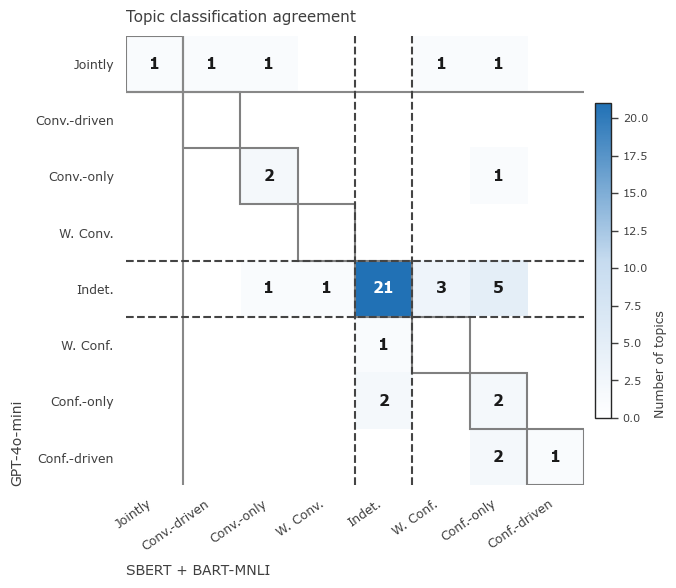

In [63]:
import matplotlib.patches as mpatches
gpt = delta_dfs["gpt"][["class"]].rename(columns={"class": "class_gpt"})
bert = delta_dfs["bert"][["class"]].rename(columns={"class": "class_bert"})

df = gpt.merge(bert, on="topic", how="inner")
class_order = [
    "jointly-driven",
    "conviction-driven",
    "conviction-only",
    "weakly conviction-driven",
    "indeterminate",
    "weakly conformity-driven",
    "conformity-only",
    "conformity-driven",
]

short_labels = [
    "Jointly",
    "Conv.-driven",
    "Conv.-only",
    "W. Conv.",
    "Indet.",
    "W. Conf.",
    "Conf.-only",
    "Conf.-driven",
]

cm = pd.crosstab(
    df["class_gpt"],
    df["class_bert"]
).reindex(index=class_order, columns=class_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))

# Custom colormap: white for 0, light blue for low, dark blue for high
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "custom_blues", ["#ffffff", "#c6dbef", "#2171b5"], N=256
)

data = cm.values

# Conviction / conformity boundary (dashed, darker)
im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0, vmax=data.max())

vmax_cap = max(5, data.max())  # cap for annotation color contrast

# Annotate cells
for i in range(len(class_order)):
    for j in range(len(class_order)):
        val = data[i, j]
        if val > 0:
            color = "white" if val > vmax_cap * 0.6 else "#1a1a1a"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=11, fontweight="bold", color=color, zorder=2)

# Diagonal highlight
for k in range(len(class_order)):
    ax.add_patch(mpatches.Rectangle(
        (k - 0.5, k - 0.5), 1, 1,
        linewidth=1.5, edgecolor="grey", facecolor="none"
    ))

# Jointly-driven separator (solid, muted)
for pos in [0.5]:
    ax.axhline(pos, color="#888888", linewidth=1.5, linestyle="-")
    ax.axvline(pos, color="#888888", linewidth=1.5, linestyle="-")

# Conviction / conformity boundary (dashed, darker) — after imshow
for pos in [3.5,4.5]:
    ax.axhline(pos, color="#444444", linewidth=1.5, linestyle="--", zorder=3)
    ax.axvline(pos, color="#444444", linewidth=1.5, linestyle="--", zorder=3)

ax.set_xticks(range(len(class_order)))
ax.set_yticks(range(len(class_order)))
ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

ax.set_xlabel("SBERT + BART-MNLI", fontsize=10, labelpad=8)
ax.set_ylabel("GPT-4o-mini", fontsize=10, labelpad=8)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Number of topics", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title("Topic classification agreement", fontsize=11, pad=10)

plt.tight_layout()
plt.savefig("./plots/FigA6.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Model classification

8 categories: 
- conviction-driven: strong tau effect, strong phi effect, and credible interval for delta > 0
- conformity-driven: strong tau effect, strong phi effect, and credible interval for delta < 0
- jointly-driven: strong tau effect, strong phi effect, but credible interval for delta includes 0
- conviction-only: strong tau effect, no strong phi effect
- conformity-only: strong phi effect, no strong tau effect
- weakly conviction-driven: no strong tau or phi effect, but credible interval for delta > 0
- weakly conformity-driven: no strong tau or phi effect, but credible interval for delta < 0
- indeterminate: no strong tau or phi effect, and credible interval for delta includes 0

In [66]:
classification_df = build_delta_df(fits['gpt'], topic_mapping_gpt)
classification_df.to_csv(f"./results/regression/gpt/classification.csv", index=False)
classification_df.head()

,topic_idx,mean_delta,ci_5,ci_95,p_tau_gt_phi,OR_tau,OR_phi,OR_tau_ci_5,OR_tau_ci_95,OR_phi_ci_5,OR_phi_ci_95,topic,tau_strong,phi_strong,conviction_leads,conviction_clear,conformity_clear,clear_direction,class
0,0,-1.897827,-2.445132,-1.365326,0.00000,6.645083,45.845954,5.216636,8.351458,27.222297,70.713703,abortion,True,True,False,False,True,True,conformity-driven
1,1,0.447686,-0.725505,1.649025,0.73000,6.539041,4.381965,2.831099,12.386826,1.551850,9.225521,affirmative action,True,False,True,False,False,False,conviction-only
2,2,-0.231772,-0.817421,0.328023,0.25575,1.807837,2.332364,1.286819,2.448516,1.398843,3.592637,animal rights,False,False,False,False,False,False,indeterminate
3,3,-4.036007,-4.815590,-3.280526,0.00000,1.315419,75.779459,0.752825,2.099085,39.711797,130.646068,barack obama,False,True,False,False,True,True,conformity-only
4,4,-1.029324,-2.117105,0.106339,0.06425,2.131256,6.506795,1.011573,3.813685,2.112194,14.083186,border fence,False,False,False,False,False,False,indeterminate
